<a href="https://colab.research.google.com/github/TuteSeta/Redes-neuronales/blob/main/Laboratorio_1b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Imgur](https://i.imgur.com/acSOZRh.png)

# Laboratorio n° 1. Parte B: Entrenamiento de Redes Neuronales

**Asignatura:** Redes Neuronales Profundas
**Bloque:** 1 — Fundamentos de Deep Learning

---

## Introducción

En el TP1 aprendiste a operar con tensores. Ahora vas a usar esas herramientas para algo concreto: **entrenar redes neuronales**.

En este trabajo vas a:

1. Implementar el **loop de entrenamiento** de una red de clasificación de imágenes desde cero.
2. Entender qué pasa en cada paso del ciclo: forward pass, cálculo de pérdida, backward pass y actualización de pesos.


### Dataset: FashionMNIST

Vamos a trabajar con el dataset **FashionMNIST**, un conjunto estándar de 70.000 imágenes en escala de grises de 28×28 píxeles de prendas de ropa, divididas en 10 categorías:

| Etiqueta | Clase |
|:-:|---|
| 0 | T-shirt/top |
| 1 | Pantalón |
| 2 | Pulóver |
| 3 | Vestido |
| 4 | Abrigo |
| 5 | Sandalia |
| 6 | Camisa |
| 7 | Zapatilla |
| 8 | Bolso |
| 9 | Bota |

---

## Instrucciones generales

- Las celdas de **setup** ya están escritas — ejecutálas sin modificar.
- Completá el código en las celdas marcadas con `# Tu código aquí`.
- Respondé las preguntas de análisis en las celdas de texto marcadas con .

---
## Ejercicios


In [1]:
# Imports
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torch.utils import data
import matplotlib.pyplot as plt

print(f"PyTorch {torch.__version__}")

PyTorch 2.10.0+cpu


### Ejercicio 1 — Implementar `load_data_fashion_mnist()`

Completá la función que descarga el dataset FashionMNIST y crea los DataLoaders.

**Pistas:**
- Usá `transforms.ToTensor()` para la transformación.
- Usá `torchvision.datasets.FashionMNIST()` con `download=True`.
- Creá los DataLoaders con `data.DataLoader()`, con `shuffle=True` para entrenamiento.


In [3]:
def load_data_fashion_mnist(batch_size):
    """
    Descarga y prepara el dataset FashionMNIST.

    Parámetros:
    batch_size (int): cantidad de imágenes por lote

    Retorna:
    train_iter: DataLoader de entrenamiento (60.000 imágenes)
    test_iter: DataLoader de prueba (10.000 imágenes)
    """
    transform = transforms.ToTensor()
    train_dataset = torchvision.datasets.FashionMNIST(
        root="./data",
        train=True,
        download=True,
        transform=transform
    )
    test_dataset = torchvision.datasets.FashionMNIST(
        root="./data",
        train=False,
        download=True,
        transform=transform
    )
    train_iter = data.DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )
    test_iter = data.DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False
    )
    return train_iter, test_iter


### Ejercicio 2 — Implementar `accuracy()`

Completá la función que cuenta cuántas predicciones fueron correctas.

**Pistas:**
- Si `y_hat` tiene más de una columna, usá `argmax` para obtener la clase predicha.
- Compará las predicciones con las etiquetas y sumá los aciertos.


In [4]:
def accuracy(y_hat, y):
    """
    Cuenta las predicciones correctas.

    Parámetros:
    y_hat: tensor de predicciones — si tiene más de una columna,
           se toma la clase con mayor puntuación (argmax).
    y: tensor de etiquetas reales (enteros)

    Retorna:
    float: cantidad de predicciones correctas
    """
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(axis=1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())


### Ejercicio 3 — Implementar `train()`

Completá el ciclo de entrenamiento que ejecuta múltiples épocas.

**Pistas:**
- En cada época, llamá a `train_epoch()` y `test_accuracy()` (que vas a implementar más adelante).
- Acumulá las métricas en una lista de tuplas `(epoch, loss, train_acc, test_acc)`.


In [6]:
def train(net, train_iter, test_iter, loss, num_epochs, updater):
    """
    Entrena la red durante num_epochs épocas completas.

    Parámetros:
    net: el modelo a entrenar
    train_iter: DataLoader de entrenamiento
    test_iter: DataLoader de prueba
    loss: función de pérdida
    num_epochs: cantidad de épocas de entrenamiento
    updater: optimizador ya configurado

    Retorna:
    metrics: lista de tuplas (epoch, loss, train_acc, test_acc)
    """
    metrics = []

    for epoch in range(num_epochs):
        # Entrenar una época
        train_loss, train_acc = train_epoch(net, train_iter, loss, updater)

        # Evaluar en test
        test_acc = test_accuracy(net, test_iter)

        # Guardar métricas
        metrics.append((epoch + 1, train_loss, train_acc, test_acc))

        # (opcional) imprimir progreso
        print(f"Epoch {epoch+1}: loss={train_loss:.4f}, train_acc={train_acc:.4f}, test_acc={test_acc:.4f}")

    return metrics


### Ejercicio 4 — Definir el modelo, la pérdida y el optimizador

Completá el código para crear:
1. Una red `nn.Sequential` con `nn.Flatten()` y una capa `nn.Linear(784, 10)`.
2. La función de pérdida `nn.CrossEntropyLoss(reduction='none')`.
3. El optimizador `torch.optim.SGD` con `lr=0.1`.


In [5]:
# Modelo base: red de una capa (regresión softmax)
# Este modelo es Sequential con:
# 1. Flatten: convierte las imágenes de (28×28) en vectores de 784 elementos
# 2. Linear(784, 10): una capa densa que produce 10 puntuaciones (una por clase)


net = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 10)
)

# Inicializamos los pesos con valores pequeños de distribución normal
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights)

# Función de pérdida CrossEntropyLoss y optimizador SGD con lr=0.1
# La función de pérdida (CrossEntropyLoss) aplica Softmax internamente.

loss = nn.CrossEntropyLoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=0.1)

print(net)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=10, bias=True)
)


---
## El ciclo de entrenamiento

Todo el entrenamiento de una red neuronal en PyTorch sigue siempre el mismo patrón de cuatro pasos, que se repite para cada lote de datos:

```
1. FORWARD PASS: pasar las entradas por el modelo → obtener predicciones
2. LOSS: comparar predicciones con etiquetas reales → calcular el error
3. BACKWARD PASS: propagar el error hacia atrás → calcular gradientes
4. UPDATE: usar los gradientes para ajustar los pesos
```

Este ciclo se repite para todos los lotes del dataset. Recorrer *todo* el dataset una vez se llama **época**.


### Ejercicio 5 — Implementar `train_epoch()`

**Objetivo:** Implementar el entrenamiento de una época completa.

Tenés que completar la función `train_epoch()`, que recibe el modelo, los datos de entrenamiento, la función de pérdida y el optimizador, y debe:

1. Iterar sobre todos los lotes del DataLoader (`train_iter`). Cada iteración devuelve un lote `(X, y)` donde:
- `X`: tensor de imágenes del lote — forma `(batch_size, 1, 28, 28)`
- `y`: tensor de etiquetas del lote — forma `(batch_size,)`
2. Para cada lote, seguir los **4 pasos del ciclo de entrenamiento**:
- **Forward:** `y_hat = net(X)` → predicciones del modelo
- **Loss:** `l = loss(y_hat, y)` → calcular la pérdida
- **Paso previo al backward:** limpiar los gradientes del paso anterior con `updater.zero_grad()`
- **Backward:** `l.mean().backward()` → calcular los gradientes
- **Update:** `updater.step()` → actualizar los pesos
3. Acumular la pérdida total y los aciertos para calcular las métricas de la época.
4. Retornar la pérdida promedio y el accuracy de entrenamiento.

> **Pistas:**
> - Llamá a `updater.zero_grad()` **antes** de hacer `.backward()` para borrar los gradientes del lote anterior. Si no lo hacés, los gradientes se acumulan y el entrenamiento no funciona.
> - Una vez terminada la época, el accuracy de entrenamiento es: `total_aciertos / total_ejemplos`
> - La pérdida promedio es: `perdida_total / total_ejemplos`
> - Para calcular los aciertos usá la función `accuracy()` que ya está definida.

In [12]:
def train_epoch(net, train_iter, loss, updater):
    """
    Entrena la red durante una sola época.

    Parámetros:
    net: el modelo a entrenar
    train_iter: DataLoader de entrenamiento
    loss: función de pérdida
    updater: optimizador ya configurado

    Retorna:
    L: pérdida promedio de la época
    Acc: accuracy de entrenamiento de la época
    """
    net.train() # indica al modelo que estamos en modo entrenamiento

    perdida_total = 0.0 # suma de todas las pérdidas del lote
    aciertos_total = 0.0 # suma de predicciones correctas
    n_total = 0 # total de ejemplos procesados
    # ── BUCLE DE ENTRENAMIENTO ────────────────────────────────────────────────
    for X, y in train_iter:
    # Tu código aquí

    # ── Paso 1: FORWARD PASS ─────────────────────────────────────────────
      y_hat = net(X)
    # ── Paso 2: CALCULAR LA PÉRDIDA ──────────────────────────────────────
      l = loss(y_hat, y)
    # ── Paso 3: LIMPIAR GRADIENTES ───────────────────────────────────────
      updater.zero_grad()
    # ── Paso 4: BACKWARD PASS ────────────────────────────────────────────
    # .mean() convierte el vector de pérdidas en un escalar.
      l.mean().backward()

      updater.step()
    # ── Paso 5: ACTUALIZAR PARÁMETROS ────────────────────────────────────
      perdida_total += l.sum().item()
      aciertos_total += accuracy(y_hat, y)
      n_total += y.numel()
    # ── Paso 6: ACUMULAR METRICAS ────────────────────────────────────────
    L = perdida_total / n_total
    Acc = aciertos_total / n_total
    # ── Paso 7: RETORNAR LAS MÉTRICAS ────────────────────────────────────
    return L, Acc


**Pregunta de análisis:**

¿Por qué es necesario llamar a `updater.zero_grad()` antes de cada `backward()`? ¿Qué pasaría si no lo hiciéramos?

Es necesario llamar a updater.zero_grad() porque en PyTorch los gradientes se acumulan en cada llamada a backward().

Si no se limpian antes de calcular los nuevos gradientes, estos se suman a los del lote anterior, lo que produce actualizaciones incorrectas de los pesos.

Como resultado, el modelo no aprende correctamente y el entrenamiento puede volverse inestable o divergir.

### Ejercicio 6 — Implementar `test_accuracy()`

**Objetivo:** Implementar la evaluación del modelo sobre los datos de prueba.

La función `test_accuracy()` mide qué tan bien generaliza el modelo a datos que **no vio durante el entrenamiento**. Para hacer esto:

1. Iterar sobre todos los lotes del DataLoader de prueba (`test_iter`).
2. Para cada lote, obtener las predicciones del modelo.
3. Acumular los aciertos y el total de ejemplos.
4. Retornar el accuracy total.

> **Pistas:**
> - Durante la evaluación, no necesitamos calcular gradientes. Usá el bloque `with torch.no_grad():` para desactivarlos.
> - Antes del loop, llamá a `net.eval()` para poner el modelo en modo evaluación. Esto afecta capas como Dropout (que en evaluación no apaga neuronas). En esta red no hay Dropout, pero es buena práctica hacerlo siempre.

In [8]:
def test_accuracy(net, test_iter):
    """
    Evalúa el accuracy del modelo sobre los datos de prueba.

    Parámetros:
    net: el modelo a evaluar
    test_iter: DataLoader de prueba

    Retorna:
    TestAcc: accuracy de prueba (entre 0 y 1)
    """
    net.eval()

    aciertos_total = 0.0
    n_total = 0

    with torch.no_grad():
        for X, y in test_iter:
            y_hat = net(X)
            aciertos_total += accuracy(y_hat, y)
            n_total += y.numel()
    # Accuracy final
    TestAcc = aciertos_total / n_total
    return TestAcc


**Pregunta de análisis:**

¿Por qué desactivamos el cálculo de gradientes durante la evaluación con `torch.no_grad()`? ¿Qué recursos ahorra?

Se desactiva para evitar el cálculo y almacenamiento del grafo de gradientes, reduciendo el uso de memoria y acelerando la evaluación.

### Ejercicio 7 — Entrenar y visualizar

**Objetivo:** Usar las funciones implementadas para entrenar efectivamente la red y analizar las curvas de entrenamiento.

**Pasos:**
1. Cargar el dataset con `load_data_fashion_mnist(batch_size=256)`.
2. Llamar a `train()` para entrenar el modelo durante **10 épocas**.
3. Graficar las curvas usando el código provisto más abajo.

> **Cómo usar `train()`:**
> La función `train()` ya la implementaste en el Ejercicio 3. Recibe:
> - `net`: el modelo (ya definido en el Ejercicio 4)
> - `train_iter`, `test_iter`: los dos DataLoaders
> - `loss`: la función de pérdida (ya definida en el Ejercicio 4)
> - `num_epochs`: cantidad de épocas
> - `updater`: el optimizador (ya definido en el Ejercicio 4)
>
> Devuelve una lista de tuplas `(epoch, loss, train_acc, test_acc)` que podés guardar en una variable.

In [15]:
# Tu código aquí: cargar datos y entrenar
# Cargar datos
batch_size = 256
train_iter, test_iter = load_data_fashion_mnist(batch_size)

# Entrenar
num_epochs = 10
metrics = train(net, train_iter, test_iter, loss, num_epochs, trainer)


Epoch 1: loss=0.7840, train_acc=0.7507, test_acc=0.7821
Epoch 2: loss=0.5704, train_acc=0.8133, test_acc=0.8079
Epoch 3: loss=0.5262, train_acc=0.8255, test_acc=0.8137
Epoch 4: loss=0.5005, train_acc=0.8331, test_acc=0.8228
Epoch 5: loss=0.4855, train_acc=0.8369, test_acc=0.8157
Epoch 6: loss=0.4744, train_acc=0.8400, test_acc=0.8268
Epoch 7: loss=0.4641, train_acc=0.8437, test_acc=0.8273
Epoch 8: loss=0.4577, train_acc=0.8454, test_acc=0.8198
Epoch 9: loss=0.4516, train_acc=0.8467, test_acc=0.8310
Epoch 10: loss=0.4470, train_acc=0.8486, test_acc=0.8323


# Código de graficación — ejecutar sin modificar
Esta función espera recibir la lista 'metrics' que devuelve train().



In [13]:
def plot_metrics(metrics, titulo="Entrenamiento"):
    """
    Grafica las curvas de entrenamiento.

    Uso:
    metrics = train(net, train_iter, test_iter, loss, 10, trainer)
    plot_metrics(metrics)

    Parámetros:
    metrics: lista de tuplas (epoch, loss, train_acc, test_acc)
    tal como la devuelve la función train()
    """
    epochs = [m[0] for m in metrics]
    losses = [m[1] for m in metrics]
    train_a = [m[2] for m in metrics]
    test_a = [m[3] for m in metrics]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, losses, 'b-o', label='Pérdida')
    ax1.set_title('Pérdida de entrenamiento')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('Pérdida')
    ax1.grid(True)
    ax1.legend()

    ax2.plot(epochs, train_a, 'g-o', label='Train accuracy')
    ax2.plot(epochs, test_a, 'r-o', label='Test accuracy')
    ax2.set_title('Accuracy')
    ax2.set_xlabel('Época')
    ax2.set_ylabel('Accuracy')
    ax2.set_ylim([0, 1])
    ax2.grid(True)
    ax2.legend()

    plt.suptitle(titulo)
    plt.tight_layout()
    plt.show()

    # Llamar a plot_metrics con tus métricas:
    # plot_metrics(metrics) ← reemplazá 'metrics' por el nombre de tu variable

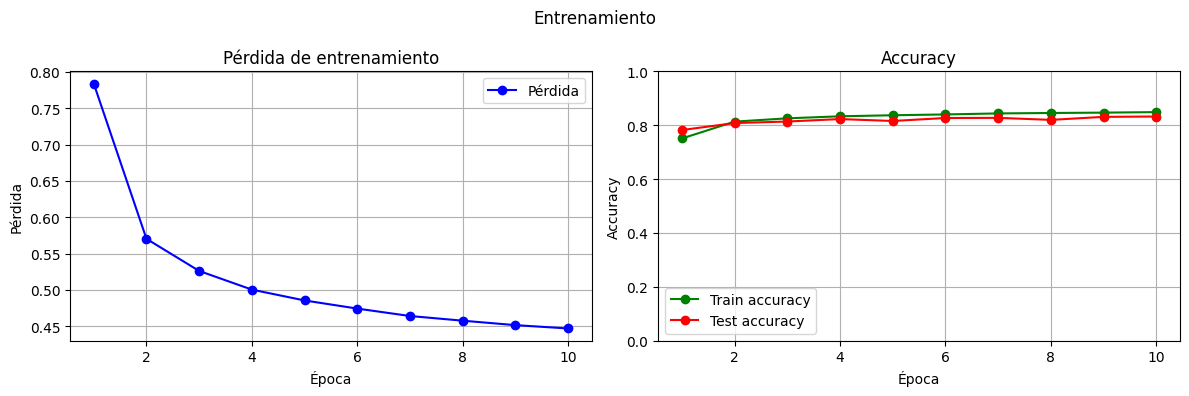

In [16]:
plot_metrics(metrics)

**Pregunta de análisis:**

Observando las curvas:
1. ¿El modelo converge? ¿Cómo se ve eso en el gráfico de pérdida?
2. ¿Hay diferencia entre el train accuracy y el test accuracy? ¿Qué indicaría si esa diferencia fuera muy grande?

Sí, el modelo converge. Esto se observa en el gráfico de pérdida, donde la pérdida disminuye progresivamente a lo largo de las épocas, pasando de aproximadamente 0.78 a 0.44.
Esta reducción indica que el modelo está aprendiendo y ajustando correctamente sus parámetros para minimizar el error.

No hay una diferencia significativa entre el train accuracy y el test accuracy. Ambos valores son cercanos y evolucionan de manera similar, lo que indica que el modelo generaliza bien.

Si la diferencia fuera muy grande (por ejemplo, train accuracy muy alto y test accuracy bajo), indicaría overfitting, es decir, que el modelo está memorizando los datos de entrenamiento pero no logra generalizar a datos nuevos.

---
## Fin del Laboratorio 1b

Completaste la primera parte del laboratorio de entrenamiento. En el Laboratorio 1c vas a construir un denoising autoencoder.